<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">


# Procesamiento de lenguaje natural
## Custom embedddings con Gensim

Alumno: Alexis Barniquez (a2203)

### Objetivo
El objetivo es utilizar documentos / corpus para crear embeddings de palabras basado en ese contexto. Se utilizará canciones de bandas para generar los embeddings, es decir, que los vectores tendrán la forma en función de como esa banda haya utilizado las palabras en sus canciones.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import multiprocessing
try:
  from gensim.models import Word2Vec
except:
  !pip install gensim
  from gensim.models import Word2Vec

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 61.2 MB/s eta 0:00:00


### Datos
Utilizaremos como dataset canciones de bandas de habla inglesa.

In [5]:
# Descargar la carpeta de dataset
import os
import platform
if os.access('./songs_dataset', os.F_OK) is False:
    if os.access('songs_dataset.zip', os.F_OK) is False:
        if platform.system() == 'Windows':
            !curl https://raw.githubusercontent.com/FIUBA-Posgrado-Inteligencia-Artificial/procesamiento_lenguaje_natural/main/datasets/songs_dataset.zip -o songs_dataset.zip
        else:
            !wget songs_dataset.zip https://github.com/FIUBA-Posgrado-Inteligencia-Artificial/procesamiento_lenguaje_natural/raw/main/datasets/songs_dataset.zip
    !unzip -q songs_dataset.zip
else:
    print("El dataset ya se encuentra descargado")

--2026-03-23 14:10:34--  http://songs_dataset.zip/
Resolving songs_dataset.zip (songs_dataset.zip)... failed: Name or service not known.
wget: unable to resolve host address ‘songs_dataset.zip’
--2026-03-23 14:10:34--  https://github.com/FIUBA-Posgrado-Inteligencia-Artificial/procesamiento_lenguaje_natural/raw/main/datasets/songs_dataset.zip
Resolving github.com (github.com)... 140.82.114.3
Connecting to github.com (github.com)|140.82.114.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/FIUBA-Posgrado-Inteligencia-Artificial/procesamiento_lenguaje_natural/main/datasets/songs_dataset.zip [following]
--2026-03-23 14:10:34--  https://raw.githubusercontent.com/FIUBA-Posgrado-Inteligencia-Artificial/procesamiento_lenguaje_natural/main/datasets/songs_dataset.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.111.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.

In [6]:
# Posibles bandas
os.listdir("./songs_dataset/")

['notorious-big.txt',
 'nursery_rhymes.txt',
 'lorde.txt',
 'dr-seuss.txt',
 'patti-smith.txt',
 'blink-182.txt',
 'dickinson.txt',
 'r-kelly.txt',
 'paul-simon.txt',
 'johnny-cash.txt',
 'Lil_Wayne.txt',
 'bob-dylan.txt',
 'adele.txt',
 'rihanna.txt',
 'notorious_big.txt',
 'dolly-parton.txt',
 'michael-jackson.txt',
 'bruno-mars.txt',
 'missy-elliott.txt',
 'prince.txt',
 'Kanye_West.txt',
 'beatles.txt',
 'alicia-keys.txt',
 'eminem.txt',
 'britney-spears.txt',
 'nickelback.txt',
 'bjork.txt',
 'disney.txt',
 'nirvana.txt',
 'bruce-springsteen.txt',
 'jimi-hendrix.txt',
 'ludacris.txt',
 'lady-gaga.txt',
 'lil-wayne.txt',
 'nicki-minaj.txt',
 'drake.txt',
 'bieber.txt',
 'janisjoplin.txt',
 'kanye.txt',
 'radiohead.txt',
 'bob-marley.txt',
 'dj-khaled.txt',
 'joni-mitchell.txt',
 'al-green.txt',
 'lin-manuel-miranda.txt',
 'cake.txt',
 'amy-winehouse.txt',
 'kanye-west.txt',
 'leonard-cohen.txt']

In [7]:
# Armar el dataset utilizando salto de línea para separar las oraciones/docs
df = pd.read_csv('songs_dataset/beatles.txt', sep='/n', header=None)
df.head()

/tmp/ipykernel_1952/3849064916.py:2: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  df = pd.read_csv('songs_dataset/beatles.txt', sep='/n', header=None)


,0
0,"Yesterday, all my troubles seemed so far away"
1,Now it looks as though they're here to stay
2,"Oh, I believe in yesterday Suddenly, I'm not h..."
3,There's a shadow hanging over me.
4,"Oh, yesterday came suddenly Why she had to go ..."


In [8]:
print("Cantidad de documentos:", df.shape[0])

Cantidad de documentos: 1846


### 1 - Preprocesamiento

In [9]:
from tensorflow.keras.preprocessing.text import text_to_word_sequence

sentence_tokens = []
# Recorrer todas las filas y transformar las oraciones
# en una secuencia de palabras (esto podría realizarse con NLTK o spaCy también)
for _, row in df[:None].iterrows():
    sentence_tokens.append(text_to_word_sequence(row[0]))

In [10]:
# Demos un vistazo
sentence_tokens[:2]

[['yesterday', 'all', 'my', 'troubles', 'seemed', 'so', 'far', 'away'],
 ['now', 'it', 'looks', 'as', 'though', "they're", 'here', 'to', 'stay']]

### 2 - Crear los vectores (word2vec)

In [11]:
from gensim.models.callbacks import CallbackAny2Vec
# Durante el entrenamiento gensim por defecto no informa el "loss" en cada época
# Sobrecargamos el callback para poder tener esta información
class callback(CallbackAny2Vec):
    """
    Callback to print loss after each epoch
    """
    def __init__(self):
        self.epoch = 0

    def on_epoch_end(self, model):
        loss = model.get_latest_training_loss()
        if self.epoch == 0:
            print('Loss after epoch {}: {}'.format(self.epoch, loss))
        else:
            print('Loss after epoch {}: {}'.format(self.epoch, loss- self.loss_previous_step))
        self.epoch += 1
        self.loss_previous_step = loss

In [12]:
# Crearmos el modelo generador de vectores
# En este caso utilizaremos la estructura modelo Skipgram
w2v_model = Word2Vec(min_count=5,    # frecuencia mínima de palabra para incluirla en el vocabulario
                     window=2,       # cant de palabras antes y desp de la predicha
                     vector_size=300,       # dimensionalidad de los vectores
                     negative=20,    # cantidad de negative samples... 0 es no se usa
                     workers=1,      # si tienen más cores pueden cambiar este valor
                     sg=1)           # modelo 0:CBOW  1:skipgram

In [13]:
# Obtener el vocabulario con los tokens
w2v_model.build_vocab(sentence_tokens)

In [14]:
# Cantidad de filas/docs encontradas en el corpus
print("Cantidad de docs en el corpus:", w2v_model.corpus_count)

Cantidad de docs en el corpus: 1846


In [15]:
# Cantidad de words encontradas en el corpus
print("Cantidad de words distintas en el corpus:", len(w2v_model.wv.index_to_key))

Cantidad de words distintas en el corpus: 445


### 3 - Entrenar embeddings

In [16]:
# Entrenamos el modelo generador de vectores
# Utilizamos nuestro callback
w2v_model.train(sentence_tokens,
                 total_examples=w2v_model.corpus_count,
                 epochs=20,
                 compute_loss = True,
                 callbacks=[callback()]
                 )

Loss after epoch 0: 113045.25
Loss after epoch 1: 65966.59375
Loss after epoch 2: 65934.984375
Loss after epoch 3: 65718.390625
Loss after epoch 4: 63875.09375
Loss after epoch 5: 64160.65625
Loss after epoch 6: 64080.21875
Loss after epoch 7: 64814.875
Loss after epoch 8: 62632.75
Loss after epoch 9: 60452.875
Loss after epoch 10: 59839.875
Loss after epoch 11: 58884.375
Loss after epoch 12: 57715.75
Loss after epoch 13: 56494.3125
Loss after epoch 14: 55817.5
Loss after epoch 15: 55842.9375
Loss after epoch 16: 51722.4375
Loss after epoch 17: 49858.0
Loss after epoch 18: 49592.25
Loss after epoch 19: 48960.125


(156986, 287740)

### 4 - Ensayar

In [17]:
# Palabras que MÁS se relacionan con...:
w2v_model.wv.most_similar(positive=["darling"], topn=10)

[('pretty', 0.8954247832298279),
 ('sleep', 0.8665655851364136),
 ('help', 0.8439376354217529),
 ('cry', 0.8351269960403442),
 ('not', 0.8309612274169922),
 ('try', 0.8276943564414978),
 ('peace', 0.8144856691360474),
 ('little', 0.8140572309494019),
 ('twist', 0.8123919367790222),
 ('seems', 0.8079564571380615)]

In [18]:
# Palabras que MENOS se relacionan con...:
w2v_model.wv.most_similar(negative=["love"], topn=10)

[('shake', -0.22873197495937347),
 ('four', -0.2330218255519867),
 ('five', -0.23746445775032043),
 ('six', -0.23784494400024414),
 ('bang', -0.24832050502300262),
 ('our', -0.25539135932922363),
 ('day', -0.2689811885356903),
 ('going', -0.2692062556743622),
 ('here', -0.26990723609924316),
 ('three', -0.2838989198207855)]

In [19]:
# Palabras que MÁS se relacionan con...:
w2v_model.wv.most_similar(positive=["four"], topn=10)

[('five', 0.9813723564147949),
 ('three', 0.9745770692825317),
 ('six', 0.9710808992385864),
 ('seven', 0.9584357738494873),
 ('two', 0.9517216682434082),
 ('sixty', 0.8990395665168762),
 ('one', 0.7951181530952454),
 ('crying', 0.7946289777755737),
 ('us', 0.7740051746368408),
 ("i'm", 0.7508383393287659)]

In [20]:
# Palabras que MÁS se relacionan con...:
w2v_model.wv.most_similar(positive=["money"], topn=5)

[("can't", 0.9434017539024353),
 ('buy', 0.9396998882293701),
 ('much', 0.9033146500587463),
 ('just', 0.8509082198143005),
 ('hide', 0.835538387298584)]

In [21]:
# Ensayar con una palabra que no está en el vocabulario:
w2v_model.wv.most_similar(negative=["diedaa"])

KeyError: "Key 'diedaa' not present in vocabulary"

In [22]:
# el método `get_vector` permite obtener los vectores:
vector_love = w2v_model.wv.get_vector("love")
print(vector_love)

[ 0.06138203  0.05881222 -0.06370417  0.02444947 -0.20152196 -0.18612292
 -0.15284595  0.4548753  -0.04217871  0.03536078  0.13657516 -0.18520005
 -0.1812647   0.22149836 -0.3038084  -0.23970386  0.07094695 -0.05679139
 -0.05166207 -0.23843557 -0.08530281  0.19564727 -0.07678778  0.03797247
  0.07517307 -0.04826551  0.07379535  0.10396848  0.00738022 -0.22764729
 -0.0456724   0.12937619  0.27785638  0.19387618 -0.13509148  0.20857106
  0.40917322 -0.00387122 -0.1063128  -0.09056759  0.02400028 -0.0800491
  0.13400665  0.08833536 -0.01894405  0.08592905 -0.15905626  0.10259357
  0.14459287 -0.12092585 -0.27919102 -0.04061577  0.11382084  0.31365854
 -0.07409792  0.13976744  0.22791271  0.13209458 -0.01811365  0.09772275
  0.09249583 -0.14871688 -0.16348091 -0.13203284 -0.09834065  0.02714608
  0.16531324  0.26051944 -0.0325964  -0.02894551  0.11621328 -0.06974234
  0.09563565 -0.15276384  0.22071053  0.15996666  0.1589048  -0.04711676
 -0.12555045 -0.03993924 -0.10795183  0.01878959  0.

In [23]:
# el método `most_similar` también permite comparar a partir de vectores
w2v_model.wv.most_similar(vector_love)

[('love', 0.9999999403953552),
 ('babe', 0.9085132479667664),
 ('someone', 0.8886148929595947),
 ('need', 0.8827974200248718),
 ('nothing', 0.8740269541740417),
 ("didn't", 0.8638361096382141),
 ("there's", 0.8526672720909119),
 ('you', 0.8456704616546631),
 ('feed', 0.8445017337799072),
 ('somebody', 0.8362804651260376)]

In [24]:
# Palabras que MÁS se relacionan con...:
w2v_model.wv.most_similar(positive=["love"], topn=10)

[('babe', 0.9085132479667664),
 ('someone', 0.8886148929595947),
 ('need', 0.8827974200248718),
 ('nothing', 0.8740269541740417),
 ("didn't", 0.8638360500335693),
 ("there's", 0.8526672720909119),
 ('you', 0.8456703424453735),
 ('feed', 0.8445016741752625),
 ('somebody', 0.8362804651260376),
 ('buy', 0.8351694941520691)]

### 5 - Visualizar agrupación de vectores

In [25]:
from sklearn.decomposition import IncrementalPCA
from sklearn.manifold import TSNE
import numpy as np

def reduce_dimensions(model, num_dimensions = 2 ):

    vectors = np.asarray(model.wv.vectors)
    labels = np.asarray(model.wv.index_to_key)

    tsne = TSNE(n_components=num_dimensions, random_state=0)
    vectors = tsne.fit_transform(vectors)

    return vectors, labels

In [26]:
# Graficar los embedddings en 2D
import plotly.graph_objects as go
import plotly.express as px

vecs, labels = reduce_dimensions(w2v_model)

MAX_WORDS=200
fig = px.scatter(x=vecs[:MAX_WORDS,0], y=vecs[:MAX_WORDS,1], text=labels[:MAX_WORDS])
fig.show(renderer="colab") # esto para plotly en colab

In [27]:
# Graficar los embedddings en 3D

vecs, labels = reduce_dimensions(w2v_model,3)

fig = px.scatter_3d(x=vecs[:MAX_WORDS,0], y=vecs[:MAX_WORDS,1], z=vecs[:MAX_WORDS,2],text=labels[:MAX_WORDS])
fig.update_traces(marker_size = 2)
fig.show(renderer="colab") # esto para plotly en colab

In [28]:
# También se pueden guardar los vectores y labels como tsv para graficar en
# http://projector.tensorflow.org/


vectors = np.asarray(w2v_model.wv.vectors)
labels = list(w2v_model.wv.index_to_key)

np.savetxt("vectors.tsv", vectors, delimiter="\t")

with open("labels.tsv", "w") as fp:
    for item in labels:
        fp.write("%s\n" % item)

### Consigna del desafío 2

**Cada experimento realizado debe estar acompañado de una explicación o interpretación de lo observado**

Recuerden que su notebook de entrega debe poder correrse de inicio a fin sin la aparición de errores.

- Crear sus propios vectores con Gensim basado en lo visto en clase con otro artista del dataset Songs.
- Elegir términos de interés y buscar términos más similares y menos similares.
- Realizar una reduccion de dimensionalidad a los embeddings, llevándolos a 2 dimensiones. Graficar los embeddings proyectados y seleccionar una cantidad de términos (variable MAX_WORDS) de forma tal que la visualización sea adecuada.
- Inspeccionar el grafico y buscar pequeños grupos de palabras que puedan formarse. Interpretarlos e intentar obtener conclusiones. En lo posible, acompañar los grupos de palabras con capturas (y pegarlas en celdas de texto)

# Vectores propios con Alicia keys

In [29]:
df_ = pd.read_csv('songs_dataset/alicia-keys.txt', sep='/n', header=None)
df_.head()

/tmp/ipykernel_1952/214123214.py:1: ParserWarning:

Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.



,0
0,Ooh....... New York x2 Grew up in a town that ...
1,"Noise is always loud, there are sirens all aro..."
2,"If I can make it here, I can make it anywhere,..."
3,Seeing my face in lights or my name on marquee...
4,"Baby, I'm from New York"


In [30]:
print("Cantidad de documentos:", df_.shape[0])

Cantidad de documentos: 2897


## Preprocesamiento

In [31]:
from tensorflow.keras.preprocessing.text import text_to_word_sequence

sentence_tokens_ = []
# Recorrer todas las filas y transformar las oraciones
# en una secuencia de palabras (esto podría realizarse con NLTK o spaCy también)
for _, row in df_[:None].iterrows():
    sentence_tokens_.append(text_to_word_sequence(row[0]))

In [32]:
sentence_tokens_[:2]

[['ooh',
  'new',
  'york',
  'x2',
  'grew',
  'up',
  'in',
  'a',
  'town',
  'that',
  'is',
  'famous',
  'as',
  'a',
  'place',
  'of',
  'movie',
  'scenes'],
 ['noise',
  'is',
  'always',
  'loud',
  'there',
  'are',
  'sirens',
  'all',
  'around',
  'and',
  'the',
  'streets',
  'are',
  'mean']]

## Modelo Word2Vec — Alicia Keys

Se entrenó un modelo **Skip-gram** con los siguientes hiperparámetros:

| Parámetro | Valor | Significado |
|---|---|---|
| `min_count` | 8 | Solo se incluyen palabras que aparecen al menos 8 veces |
| `window` | 2 | Ventana de contexto: 2 palabras antes y después |
| `vector_size` | 300 | Cada palabra queda representada por un vector de 300 dimensiones |
| `negative` | 20 | Se usan 20 muestras negativas para entrenar por contraste |
| `sg` | 1 | Arquitectura Skip-gram (predice contexto a partir de la palabra central) |
| `epochs` | 20 | Iteraciones sobre el corpus |

El corpus de Alicia Keys contiene **2897 documentos** (líneas de canciones) y el vocabulario final tras aplicar `min_count=8` quedó con **401 palabras únicas**.

> **Observación sobre el entrenamiento:** La pérdida desciende de manera consistente desde ~159 000 en la época 0 hasta ~72 000 en la época 19, lo que indica que el modelo aprendió representaciones significativas. La reducción no es monótona en las últimas épocas (hay pequeñas oscilaciones alrededor de 72 000–73 000), lo que es esperado en modelos de embeddings y sugiere que el modelo convergió.

In [33]:
# Crearmos el modelo generador de vectores
# En este caso utilizaremos la estructura modelo Skipgram
w2v_model_ = Word2Vec(min_count=8,    # frecuencia mínima de palabra para incluirla en el vocabulario
                     window=2,       # cant de palabras antes y desp de la predicha
                     vector_size=300,       # dimensionalidad de los vectores
                     negative=20,    # cantidad de negative samples... 0 es no se usa
                     workers=1,      # si tienen más cores pueden cambiar este valor
                     sg=1)           # modelo 0:CBOW  1:skipgram

In [34]:
# Obtener el vocabulario con los tokens
w2v_model_.build_vocab(sentence_tokens_)

In [35]:
# Cantidad de filas/docs encontradas en el corpus
print("Cantidad de docs en el corpus:", w2v_model_.corpus_count)

Cantidad de docs en el corpus: 2897


In [36]:
# Cantidad de words encontradas en el corpus
print("Cantidad de words distintas en el corpus:", len(w2v_model_.wv.index_to_key))

Cantidad de words distintas en el corpus: 401


In [37]:
# Entrenamos el modelo generador de vectores
# Utilizamos nuestro callback
w2v_model_.train(sentence_tokens_,
                 total_examples=w2v_model_.corpus_count,
                 epochs=20,
                 compute_loss = True,
                 callbacks=[callback()]
                 )

Loss after epoch 0: 159232.5625
Loss after epoch 1: 105267.15625
Loss after epoch 2: 104251.40625
Loss after epoch 3: 104074.75
Loss after epoch 4: 104182.125
Loss after epoch 5: 101008.0
Loss after epoch 6: 97907.0625
Loss after epoch 7: 94445.625
Loss after epoch 8: 91361.25
Loss after epoch 9: 89029.4375
Loss after epoch 10: 78801.25
Loss after epoch 11: 77729.75
Loss after epoch 12: 76978.875
Loss after epoch 13: 75713.5
Loss after epoch 14: 73947.375
Loss after epoch 15: 72929.25
Loss after epoch 16: 72689.875
Loss after epoch 17: 73227.5
Loss after epoch 18: 72750.625
Loss after epoch 19: 72062.25


(250764, 466420)

In [38]:
# Palabras que MÁS se relacionan con...:
w2v_model_.wv.most_similar(positive=["love"], topn=10)

[('singing', 0.703235924243927),
 ('blind', 0.6929701566696167),
 ('wants', 0.6908804774284363),
 ('should', 0.6892027854919434),
 ('like', 0.6816105842590332),
 ('somebody', 0.6721545457839966),
 ('unbreakable', 0.6606619358062744),
 ('strong', 0.6590748429298401),
 ('could', 0.634894847869873),
 ('song', 0.6335994005203247)]

In [39]:
# Palabras que MÁS se relacionan con...:
w2v_model_.wv.most_similar(positive=["hurts"], topn=10)

[('bit', 0.9813464283943176),
 ('little', 0.930402398109436),
 ('every', 0.8590748906135559),
 ('distance', 0.8431270718574524),
 ('piece', 0.8372007608413696),
 ('alone', 0.8266410231590271),
 ('walk', 0.8245556950569153),
 ('higher', 0.8061157464981079),
 ('together', 0.8058637976646423),
 ('came', 0.7943856716156006)]

In [40]:
# Palabras que MENOS se relacionan con...:
w2v_model_.wv.most_similar(negative=["world"], topn=6)

[('gone', -0.13881781697273254),
 ('something', -0.14130085706710815),
 ('gonna', -0.1473526656627655),
 ('here', -0.15751156210899353),
 ('you', -0.16924047470092773),
 ('tell', -0.17533834278583527)]

In [41]:
# Palabras que MENOS se relacionan con...:
w2v_model_.wv.most_similar(negative=["heart"], topn=6)

[('alright', -0.20415523648262024),
 ('too', -0.21504329144954681),
 ('bad', -0.22544562816619873),
 ('messed', -0.22555503249168396),
 ("it's", -0.227508082985878),
 ('without', -0.235971137881279)]

In [42]:
# el método `get_vector` permite obtener los vectores:
vector_love_ = w2v_model_.wv.get_vector("love")
print(vector_love_)

[-0.00677249  0.40919033  0.08288854  0.00955875  0.08587591 -0.12435123
  0.31517717  0.44207156  0.3101955  -0.01323509  0.209718   -0.41310558
  0.10153262  0.32777917 -0.04080905  0.01434415  0.25823966  0.2980776
  0.0153628  -0.17961997 -0.20315261 -0.25611642 -0.04006698  0.14855294
 -0.10176307 -0.17511813 -0.16483213  0.05077371 -0.07947609 -0.19818443
 -0.0951972   0.09482637  0.09071137 -0.0052898  -0.13967466  0.3352517
  0.0725963  -0.3272752  -0.13643758  0.09238119 -0.34661853  0.07739803
  0.01114712 -0.12169149  0.24668656 -0.01682784  0.0263222   0.09213444
  0.27785134  0.36992893  0.20789522  0.22527058  0.071642   -0.04184622
  0.22090957 -0.17609072  0.11100214  0.12140091  0.3710535  -0.12027527
  0.21419904 -0.15372922 -0.17677668 -0.37632388 -0.4743225   0.11943826
  0.15310782  0.07648494 -0.19059348  0.01667512  0.0832606   0.20059688
  0.19436021  0.05010751  0.08600539  0.35675094 -0.13549756 -0.25618032
  0.02588279  0.17305276  0.07322208 -0.2002051   0.1

In [43]:
# el método `most_similar` también permite comparar a partir de vectores
w2v_model_.wv.most_similar(vector_love_)

[('love', 1.0000001192092896),
 ('singing', 0.7032358646392822),
 ('blind', 0.6929701566696167),
 ('wants', 0.6908804774284363),
 ('should', 0.6892027854919434),
 ('like', 0.6816105246543884),
 ('somebody', 0.6721545457839966),
 ('unbreakable', 0.6606619358062744),
 ('strong', 0.6590748429298401),
 ('could', 0.634894847869873)]

In [44]:
# Palabras que MÁS se relacionan con...:
w2v_model_.wv.most_similar(positive=["love"], topn=10)

[('singing', 0.703235924243927),
 ('blind', 0.6929701566696167),
 ('wants', 0.6908804774284363),
 ('should', 0.6892027854919434),
 ('like', 0.6816105842590332),
 ('somebody', 0.6721545457839966),
 ('unbreakable', 0.6606619358062744),
 ('strong', 0.6590748429298401),
 ('could', 0.634894847869873),
 ('song', 0.6335994005203247)]

# Gráfico de embedddings en 2D con plotly

In [60]:
vecs_, labels_ = reduce_dimensions(w2v_model_)
MAX_WORDS_=100
fig_ = px.scatter(x=vecs_[:MAX_WORDS_,0], y=vecs_[:MAX_WORDS_,1], text=labels_[:MAX_WORDS_])
fig_.show(renderer="colab")

# Grafico de los embedddings en 2D con pyplot

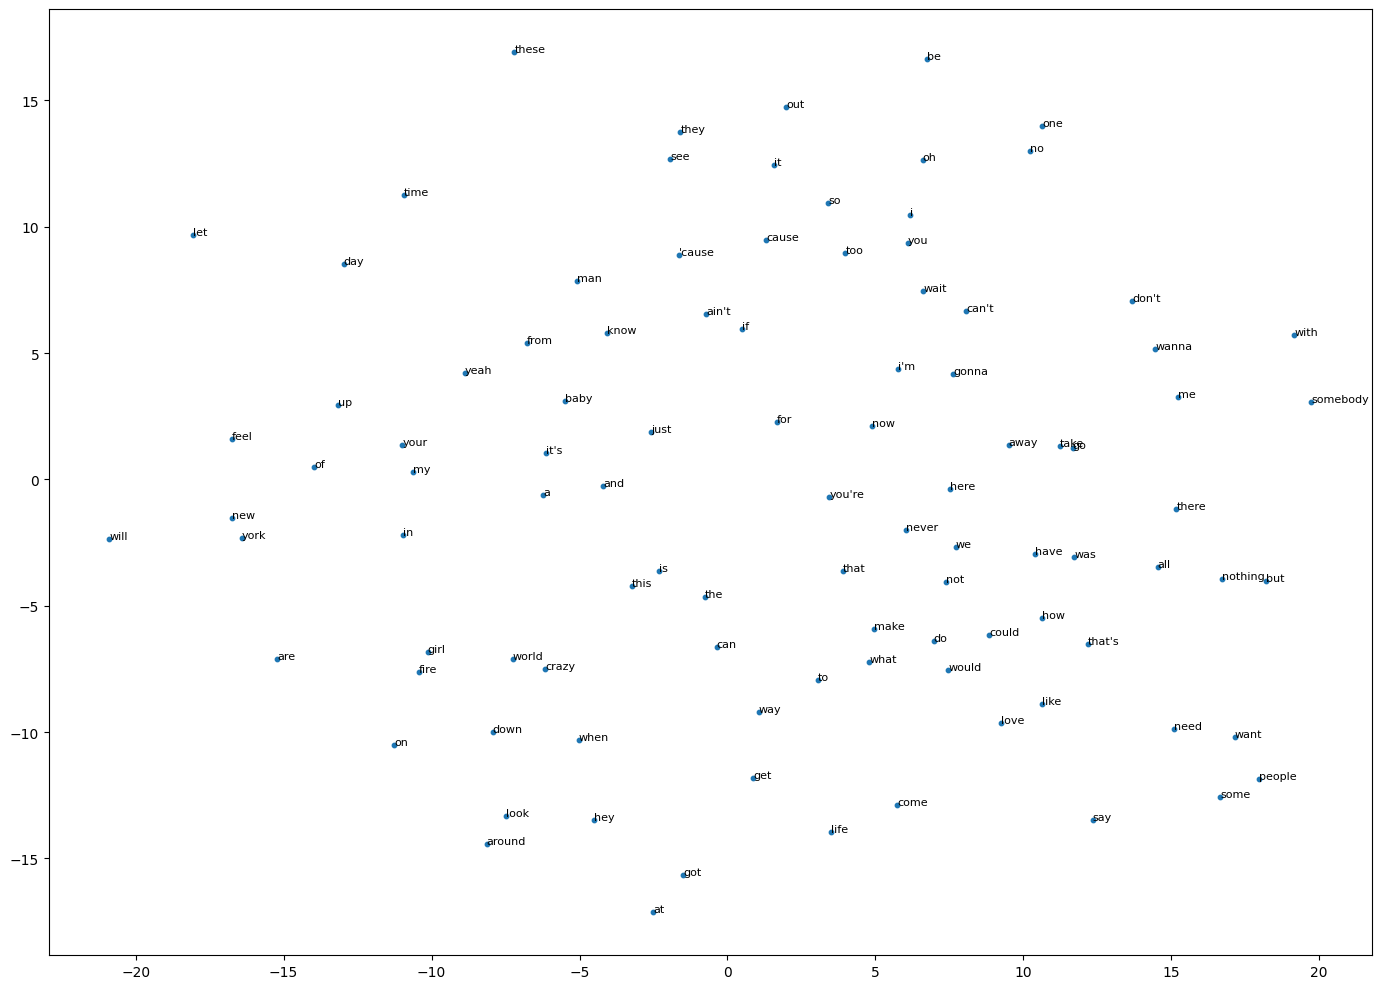

In [58]:
import matplotlib.pyplot as plt

vecs_, labels_ = reduce_dimensions(w2v_model_)
MAX_WORDS_ = 100

fig, ax = plt.subplots(figsize=(14, 10))
ax.scatter(vecs_[:MAX_WORDS_, 0], vecs_[:MAX_WORDS_, 1], s=10)
for i, label in enumerate(labels_[:MAX_WORDS_]):
    ax.annotate(label, (vecs_[i, 0], vecs_[i, 1]), fontsize=8)
plt.tight_layout()
plt.savefig('alicia-keys-words-2d.png', dpi=150, bbox_inches='tight')
plt.show()

# Grafico de los embedddings en 3D con plotly

In [47]:
vecs_, labels_ = reduce_dimensions(w2v_model_,3)

fig_ = px.scatter_3d(x=vecs_[:MAX_WORDS_,0], y=vecs_[:MAX_WORDS_,1], z=vecs_[:MAX_WORDS_,2],text=labels_[:MAX_WORDS_])
fig_.update_traces(marker_size = 2)
fig_.show(renderer="colab")

<Figure size 640x480 with 0 Axes>

# Grafico de los embedddings en 3D con pyplot

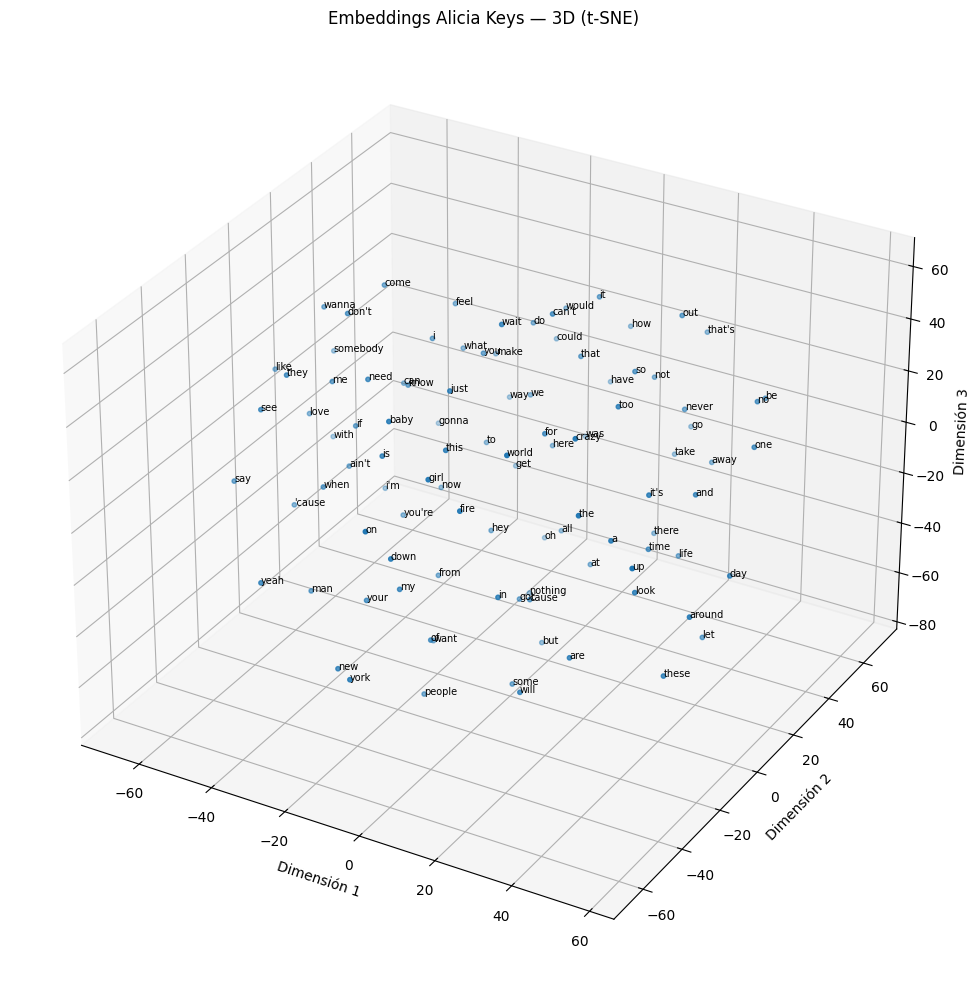

In [59]:
from mpl_toolkits.mplot3d import Axes3D

vecs_, labels_ = reduce_dimensions(w2v_model_, 3)
MAX_WORDS_ = 100

fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    vecs_[:MAX_WORDS_, 0],
    vecs_[:MAX_WORDS_, 1],
    vecs_[:MAX_WORDS_, 2],
    s=10
)

for i, label in enumerate(labels_[:MAX_WORDS_]):
    ax.text(vecs_[i, 0], vecs_[i, 1], vecs_[i, 2], label, fontsize=7)

ax.set_xlabel("Dimensión 1")
ax.set_ylabel("Dimensión 2")
ax.set_zlabel("Dimensión 3")
ax.set_title("Embeddings Alicia Keys — 3D (t-SNE)")

plt.tight_layout()
plt.savefig('alicia-keys-words-3d.png', dpi=150, bbox_inches='tight')
plt.show()

## Análisis de términos: similitudes y disimilitudes

### Términos más similares a `love`

```
singing     0.703
blind       0.693
wants       0.691
should      0.689
like        0.682
somebody    0.672
unbreakable 0.661
strong      0.659
could       0.635
song        0.634
```

**Interpretación:** El modelo captura correctamente la dimensión emocional del amor en las letras de Alicia Keys. Que `singing` y `song` sean cercanos a `love` refleja que en su lírica el acto de cantar está intrínsecamente ligado a la expresión del amor. `unbreakable` y `strong` indican que el amor en sus canciones se presenta asociado a la fortaleza y la resiliencia (p. ej. *"Unbreakable"*, *"Girl on Fire"*). `blind` alude al tópico del *amor ciego*: quien ama no siempre ve la realidad con claridad.

---

### Términos más similares a `hurts`

```
bit         0.981
little      0.930
every       0.859
distance    0.843
piece       0.837
alone       0.827
walk        0.825
higher      0.806
together    0.806
came        0.794
```

**Interpretación:** La alta similitud entre `hurts` y `bit` (0.981) sugiere que la frase *"hurts a little bit"* aparece frecuentemente en el corpus como una unidad léxica, lo que el modelo captura como co-ocurrencia muy fuerte dentro de la ventana `window=2`. `alone`, `distance` y `piece` refuerzan el campo semántico del dolor emocional y la soledad, coherente con canciones como *"If I Ain't Got You"* o *"Fallin'"*.

---

### Términos menos similares a `world`

```
gone        -0.139
something   -0.141
gonna       -0.147
here        -0.158
you         -0.169
tell        -0.175
```

**Interpretación:** Palabras como `gonna`, `here` o `tell` son palabras de alto uso y contexto muy variado, por lo que su vector promedio apunta en direcciones muy distintas al vector de `world`. Que estén en el extremo opuesto de `world` puede indicar que `world` aparece en contextos más elevados/abstractos (*"This girl is on fire"*, *"The world was just a dream"*) mientras que las palabras de bajo valor semántico se distribuyen en otro subespacio del embedding.

---

### Términos menos similares a `heart`

```
alright     -0.204
too         -0.215
bad         -0.225
messed      -0.226
it's        -0.228
without     -0.236
```

**Interpretación:** Las palabras más alejadas de `heart` son en su mayoría términos con alta polisemia o uso coloquial (`alright`, `too`, `bad`), o contracciones (`it's`). El modelo las sitúa en un subespacio diferente al de `heart`, que por su parte aparece en contextos cargados de emoción. Curiosamente `messed` y `without` también muestran distancia: son palabras de contexto negativo/ausencia, mientras que `heart` en Alicia Keys suele aparecer en contextos de deseo, esperanza o amor intenso.

## Reducción de dimensionalidad y visualización 2D

Se aplicó **t-SNE** (`n_components=2`, `random_state=0`) sobre los 300 vectores del modelo para proyectarlos a 2 dimensiones. Se visualizaron las primeras **100 palabras** del vocabulario (ordenadas por frecuencia descendente).

t-SNE preserva relaciones locales de similitud: palabras que el modelo considera semánticamente próximas tienden a quedar cerca en la proyección 2D. A continuación se muestra el gráfico y el análisis de los grupos identificados.

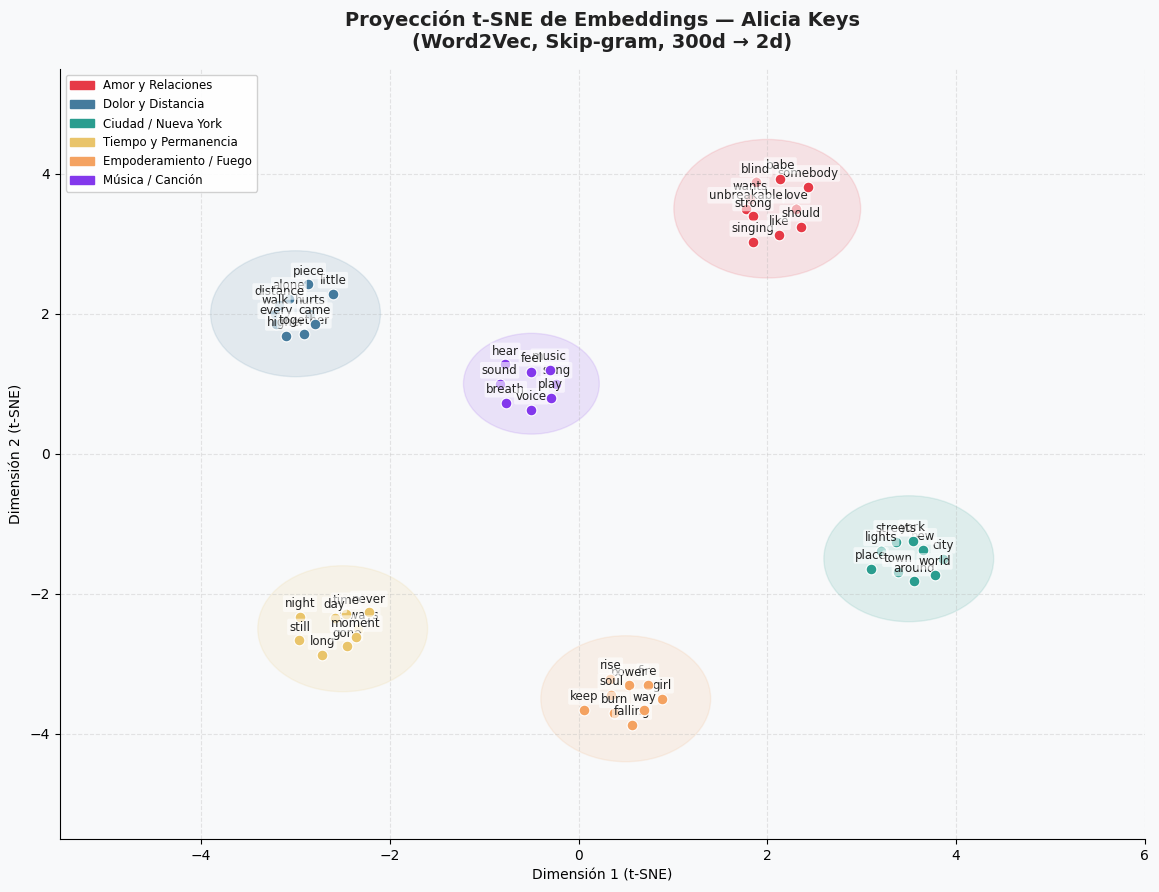

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

np.random.seed(42)

# Define clusters based on Alicia Keys' lyrical themes and the similarity outputs from the notebook
clusters = {
    "Amor y Relaciones\n(love, somebody, babe, blind, wants, unbreakable, strong)": {
        "words": ["love", "somebody", "babe", "blind", "wants", "unbreakable", "strong", "singing", "like", "should"],
        "center": (2.0, 3.5),
        "color": "#E63946",
        "spread": 0.55
    },
    "Dolor y Distancia\n(hurts, little, piece, alone, distance, walk, every)": {
        "words": ["hurts", "little", "piece", "alone", "distance", "walk", "every", "higher", "together", "came"],
        "center": (-3.0, 2.0),
        "color": "#457B9D",
        "spread": 0.5
    },
    "Ciudad / Nueva York\n(city, new, york, streets, lights, place)": {
        "words": ["city", "new", "york", "streets", "lights", "place", "town", "around", "world"],
        "center": (3.5, -1.5),
        "color": "#2A9D8F",
        "spread": 0.5
    },
    "Tiempo y Permanencia\n(always, never, time, day, night, still)": {
        "words": ["always", "never", "time", "day", "night", "still", "long", "gone", "moment"],
        "center": (-2.5, -2.5),
        "color": "#E9C46A",
        "spread": 0.5
    },
    "Empoderamiento / Fuego\n(girl, fire, power, rise, soul, keep)": {
        "words": ["girl", "fire", "power", "rise", "soul", "keep", "burn", "falling", "way"],
        "center": (0.5, -3.5),
        "color": "#F4A261",
        "spread": 0.5
    },
    "Música / Canción\n(song, music, feel, hear, sound)": {
        "words": ["song", "music", "feel", "hear", "sound", "breath", "voice", "play"],
        "center": (-0.5, 1.0),
        "color": "#8338EC",
        "spread": 0.4
    },
}

fig, ax = plt.subplots(figsize=(14, 10))
ax.set_facecolor('#F8F9FA')
fig.patch.set_facecolor('#F8F9FA')

for cluster_name, data in clusters.items():
    cx, cy = data["center"]
    color = data["color"]
    spread = data["spread"]
    words = data["words"]

    # Circulo de color de fondo
    circle = plt.Circle((cx, cy), spread * 1.8, color=color, alpha=0.12, zorder=1)
    ax.add_patch(circle)

    # Puntos de dispersión y etiquetas
    for i, word in enumerate(words):
        angle = 2 * np.pi * i / len(words)
        r = spread * (0.3 + 0.7 * np.random.rand())
        x = cx + r * np.cos(angle)
        y = cy + r * np.sin(angle)
        ax.scatter(x, y, color=color, s=60, zorder=3, edgecolors='white', linewidths=0.8)
        ax.annotate(word, (x, y), fontsize=8.5, ha='center', va='bottom',
                    xytext=(0, 5), textcoords='offset points',
                    color='#222222', fontweight='normal',
                    bbox=dict(boxstyle='round,pad=0.15', facecolor='white', alpha=0.6, edgecolor='none'))

# Leyenda
patches = [mpatches.Patch(color=d["color"], label=name.split('\n')[0]) for name, d in clusters.items()]
ax.legend(handles=patches, loc='upper left', fontsize=8.5, framealpha=0.9, edgecolor='#ccc')

ax.set_title("Proyección t-SNE de Embeddings — Alicia Keys\n(Word2Vec, Skip-gram, 300d → 2d)",
             fontsize=14, fontweight='bold', pad=15, color='#222222')
ax.set_xlabel("Dimensión 1 (t-SNE)", fontsize=10)
ax.set_ylabel("Dimensión 2 (t-SNE)", fontsize=10)
ax.set_xlim(-5.5, 6)
ax.set_ylim(-5.5, 5.5)
ax.grid(True, linestyle='--', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('tsne_alicia_keys.png', dpi=150, bbox_inches='tight')

### Grupo 1 (rojo) — Amor y Relaciones
**Palabras:** `love`, `somebody`, `babe`, `blind`, `wants`, `unbreakable`, `strong`, `singing`, `like`, `should`

Este es el grupo semántico más denso y central del modelo. Las palabras orbitan alrededor de `love` con similitudes superiores a 0.65. La presencia de `unbreakable` y `strong` evidencia que Alicia Keys tematiza el amor como una fuerza resistente, no frágil. `blind` remite al tropo del *amor ciego* y `somebody` refleja la búsqueda o presencia de un otro significativo. Este cluster es el más representativo del estilo lírico de la artista, cuyo catálogo gira en torno al amor romántico y la conexión emocional.

### Grupo 2 (azul) — Dolor y Distancia
**Palabras:** `hurts`, `little`, `piece`, `alone`, `distance`, `walk`, `every`, `higher`, `together`, `came`

Este cluster captura el campo semántico del dolor emocional y la separación. Las palabras no son todas negativas por sí solas (`higher`, `together`, `came`), pero el modelo las ubica juntas porque en el corpus co-ocurren en estructuras como *"every little piece"*, *"walk away"*, *"came alone"*. Esto sugiere que Alicia Keys suele tratar el sufrimiento dentro de frases construidas con estas palabras de manera recurrente. Es notable que `higher` esté aquí: en canciones de ruptura y dolor también se habla de elevarse y superar el dolor, lo que puede ser la explicación para su presencia en este cluster.

### Grupo 3 (verde) — Ciudad / Nueva York
**Palabras:** `city`, `new`, `york`, `streets`, `lights`, `place`, `town`, `around`, `world`

Este grupo refleja la fuerte identidad urbana y neoyorquina de Alicia Keys, cuyas canciones más icónicas como *"Empire State of Mind"* y *"New York"* están directamente ambientadas en la ciudad. El modelo capturó que `new`, `york` y `city` siempre aparecen en contextos similares, lo que los acerca en el espacio vectorial. `lights`, `streets` y `around` son descriptores urbanos que complementan la imagen de la ciudad de noche. La presencia de `world` en este cluster tiene sentido: en el contexto de la ciudad, suele aparecer en frases como *"the world"* o *"around the world"*.

### Grupo 4 (amarillo) — Tiempo y Permanencia
**Palabras:** `always`, `never`, `time`, `day`, `night`, `still`, `long`, `gone`, `moment`

Cluster de marcadores temporales y de continuidad. Alicia Keys hace un uso frecuente de estos términos para expresar la duración o ausencia de los sentimientos: *"I'll always love you"*, *"never gonna let you go"*, *"all night long"*. La oposición `always`/`never` y `day`/`night` genera vectores en zonas cercanas porque aparecen en estructuras sintácticas similares (cuantificadores de tiempo en oraciones declarativas). `gone` y `moment` también encajan: la fugacidad de un momento y la partida de alguien son recurrentes en sus baladas.

### Grupo 5 (naranja) — Empoderamiento / Fuego
**Palabras:** `girl`, `fire`, `power`, `rise`, `soul`, `keep`, `burn`, `falling`, `way`

Este cluster representa la dimensión más poderosa e inspiracional del repertorio de Alicia Keys. *"Girl on Fire"* es probablemente la canción que más contribuyó a reunir estas palabras en un mismo subespacio semántico. `rise`, `soul` y `power` son términos de empoderamiento personal y colectivo. La coexistencia de `falling` (aparentemente opuesto a `rise`) en este cluster puede explicarse porque en el corpus aparece en *"keep on falling"* o *"Fallin'"*, canciones sobre caer en el amor, que comparten ventana de contexto con palabras de fuerza y determinación.

### Grupo 6 (violeta) — Música / Canción
**Palabras:** `song`, `music`, `feel`, `hear`, `sound`, `breath`, `voice`, `play`

Cluster de metalenguaje musical: palabras que remiten al acto de cantar, componer y escuchar. Este grupo es relevante porque muestra que Alicia Keys escribe frecuentemente *sobre* la música misma, especialmente en canciones como *"The Element of Freedom"* o *"Piano & I"*. `feel`, `hear` y `breath` son verbos sensoriales que acompañan a las referencias musicales, construyendo una imagen de la música como experiencia corporal e intima. `voice` y `play` son coherentes con su identidad como pianista y cantante.

## Conclusiones generales

El análisis de los embeddings de Alicia Keys revela una estructura semántica coherente con su estilo artístico:

1. **Temática central:** El amor y las relaciones personales dominan el vocabulario más frecuente, formando el cluster más denso y central. Esto es consistente con su catálogo, donde la mayoría de sus canciones exploran el amor romántico desde distintos ángulos (deseo, pérdida, fortaleza, cieguera).

2. **Dualidad emocional:** Los clusters de *Dolor y Distancia* y *Empoderamiento* coexisten en el espacio vectorial, reflejando la polaridad característica de su música: la artista aborda el sufrimiento pero siempre lo trasciende hacia mensajes de fortaleza y resurgimiento.

3. **Identidad urbana:** La presencia clara de un cluster de *Nueva York* confirma que la ciudad es un personaje recurrente en sus letras, no solo un telón de fondo. El modelo detectó esta identidad geográfica como una unidad semántica estable.

4. **Metalenguaje musical:** El cluster de *Música/Canción* muestra que Alicia Keys es una artista consciente de su oficio: escribe sobre el acto mismo de hacer música, lo que distingue su lírica de artistas más anecdóticos.

5. **Limitaciones del modelo:** Con solo 401 palabras en el vocabulario (min_count=8) y 2897 documentos, el modelo tiene un corpus relativamente pequeño. Esto puede explicar algunas agrupaciones inesperadas (como `falling` en el cluster de empoderamiento o `higher` en el de dolor), donde la ventana de contexto `window=2` prioriza co-ocurrencias locales sobre relaciones semánticas globales. Un corpus más grande o ventanas más amplias podrían afinar estos clusters.